# Exploration: Distribution Check for Single Family Residential Sales

This notebook explores the distributions of `ClosePrice`, `LivingArea`, `Bedrooms`, `Bathrooms`, and `LotSize`.

Restrict the analysis to:

- `PropertyType = Residential`
- `PropertySubType = SingleFamilyResidence`

For `LotSize`, I use `LotSizeSquareFeet` because it is a numeric lot size field.

## Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the merged data

In [2]:
data = pd.read_csv('../data/merged_crmls_sold.csv', low_memory=False)

data.head()

,source_period,source_file,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
0,2022-02,CRMLSSold20220101_20231231_filled.csv,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,...,0.0,ABC Unified,92708,0.0,NaN,NaN,False,False,NaN,NaN
1,2022-02,CRMLSSold20220101_20231231_filled.csv,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,...,1.0,Apple Valley Unified,92308,0.0,43000.0,NaN,False,False,NaN,NaN
2,2022-04,CRMLSSold20220101_20231231_filled.csv,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,...,1.0,Solana Beach,92075,370.0,NaN,NaN,False,False,NaN,NaN
3,2022-01,CRMLSSold20220101_20231231_filled.csv,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,...,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,NaN,NaN
4,2022-01,CRMLSSold20220101_20231231_filled.csv,"Carpet,Tile",NaN,NaN,NaN,NaN,598888.0,556365290,steven@westsideres.com,...,1.0,Other,95111,300.0,2738.0,NaN,False,False,NaN,NaN


In [3]:
print('Rows:', len(data))
print('Columns:', data.shape[1])

Rows: 818778
Columns: 84


## 2. Filter to the Single Family Residence property type


In [4]:
single_family = data[
    (data['PropertyType'] == 'Residential') &
    (data['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print('Rows after filtering:', len(single_family))
single_family.head()

Rows after filtering: 412015


,source_period,source_file,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
3,2022-01,CRMLSSold20220101_20231231_filled.csv,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,...,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,NaN,NaN
6,2022-01,CRMLSSold20220101_20231231_filled.csv,NaN,True,NaN,NaN,False,565000.0,556365286,joseph@labelrealtygroup.com,...,1.0,Rim of the World,92352,0.0,3397.0,NaN,False,False,NaN,NaN
7,2022-03,CRMLSSold20220101_20231231_filled.csv,NaN,False,NaN,NaN,False,349999.0,556365284,eaguayo08@gmail.com,...,2.0,Fontana Unified,92336,0.0,9900.0,NaN,False,False,NaN,NaN
12,2022-01,CRMLSSold20220101_20231231_filled.csv,"Carpet,Tile",True,NaN,NaN,True,599000.0,556364261,gcrb714@gmail.com,...,2.0,NaN,92234,195.0,6098.0,NaN,False,False,NaN,NaN
14,2022-01,CRMLSSold20220101_20231231_filled.csv,NaN,True,NaN,NaN,False,399990.0,556363890,allegra@3treehomes.com,...,2.0,Paradise Unified,95969,0.0,12197.0,NaN,False,False,NaN,NaN


## 3. Clean the numeric columns

Only read `PropertyType`, `PropertySubType`, `ClosePrice`, `LivingArea`, `BedroomsTotal`, `BathroomsTotalInteger`, `LotSizeSquareFeet` columns for this EDA

Target Variable: `ClosePrice`

- Rename:
    - `BedroomsTotal` as Bedrooms
    - `BathroomsTotalInteger` as Bathrooms
    - `LotSizeSquareFeet` as LotSize

In [5]:
numeric_columns = [
    'ClosePrice',
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeSquareFeet'
]

for column in numeric_columns:
    single_family[column] = pd.to_numeric(single_family[column], errors='coerce')

single_family = single_family.rename(columns={
    'BedroomsTotal': 'Bedrooms',
    'BathroomsTotalInteger': 'Bathrooms',
    'LotSizeSquareFeet': 'LotSize'
})

eda_columns = ['ClosePrice', 'LivingArea', 'Bedrooms', 'Bathrooms', 'LotSize']

single_family[eda_columns].head()


,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
3,2499999.0,2645.0,4.0,4.0,13376.0
6,640000.0,2070.0,3.0,3.0,3397.0
7,438000.0,1174.0,3.0,2.0,9900.0
12,615000.0,1996.0,2.0,2.0,6098.0
14,399990.0,1422.0,3.0,2.0,12197.0


## 4. Missing values

Before looking at distributions, I check how many missing values each variable has.


In [6]:
missing_values = single_family[eda_columns].isna().sum()
missing_percent = single_family[eda_columns].isna().mean() * 100

missing_table = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percent': missing_percent
})

missing_table

,missing_count,missing_percent
ClosePrice,2,0.000485
LivingArea,216,0.052425
Bedrooms,0,0.000000
Bathrooms,75,0.018203
LotSize,7039,1.708433


## 5. Summary statistics

This table gives the basic distribution summary for each variable.


In [7]:
summary_table = single_family[eda_columns].describe()
summary_table

,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
count,4.120130e+05,4.117990e+05,412015.000000,411940.000000,4.049760e+05
mean,1.285743e+06,2.037899e+03,3.477757,2.611798,2.453932e+05
std,5.161980e+06,3.748256e+03,0.960323,1.180837,1.378928e+07
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,6.200000e+05,1.374000e+03,3.000000,2.000000,5.663000e+03
50%,8.900000e+05,1.801000e+03,3.000000,2.000000,7.250000e+03
75%,1.425000e+06,2.419000e+03,4.000000,3.000000,1.035000e+04
max,9.895000e+08,2.308680e+06,45.000000,175.000000,2.087221e+09


## 7. Skewness

Positive skewness means the distribution has a long right tail.


In [8]:
skew_table = single_family[eda_columns].skew().to_frame(name='skewness')
skew_table

,skewness
ClosePrice,140.028232
LivingArea,566.112093
Bedrooms,1.015797
Bathrooms,14.401626
LotSize,95.265888


## 10. Simple outlier check

I use the IQR rule to count possible low and high outliers.


In [9]:
outlier_rows = []

for column in eda_columns:
    clean_values = single_family[column].dropna()

    q1 = clean_values.quantile(0.25)
    q3 = clean_values.quantile(0.75)
    iqr = q3 - q1

    low_limit = q1 - 1.5 * iqr
    high_limit = q3 + 1.5 * iqr

    low_outliers = (clean_values < low_limit).sum()
    high_outliers = (clean_values > high_limit).sum()

    outlier_rows.append({
        'variable': column,
        'low_limit': low_limit,
        'high_limit': high_limit,
        'low_outliers': low_outliers,
        'high_outliers': high_outliers
    })

outlier_table = pd.DataFrame(outlier_rows)
outlier_table


,variable,low_limit,high_limit,low_outliers,high_outliers
0,ClosePrice,-587500.0,2632500.0,0,30553
1,LivingArea,-193.5,3986.5,0,17174
2,Bedrooms,1.5,5.5,2942,9060
3,Bathrooms,0.5,4.5,175,23753
4,LotSize,-1367.5,17380.5,0,55170


## Histograms


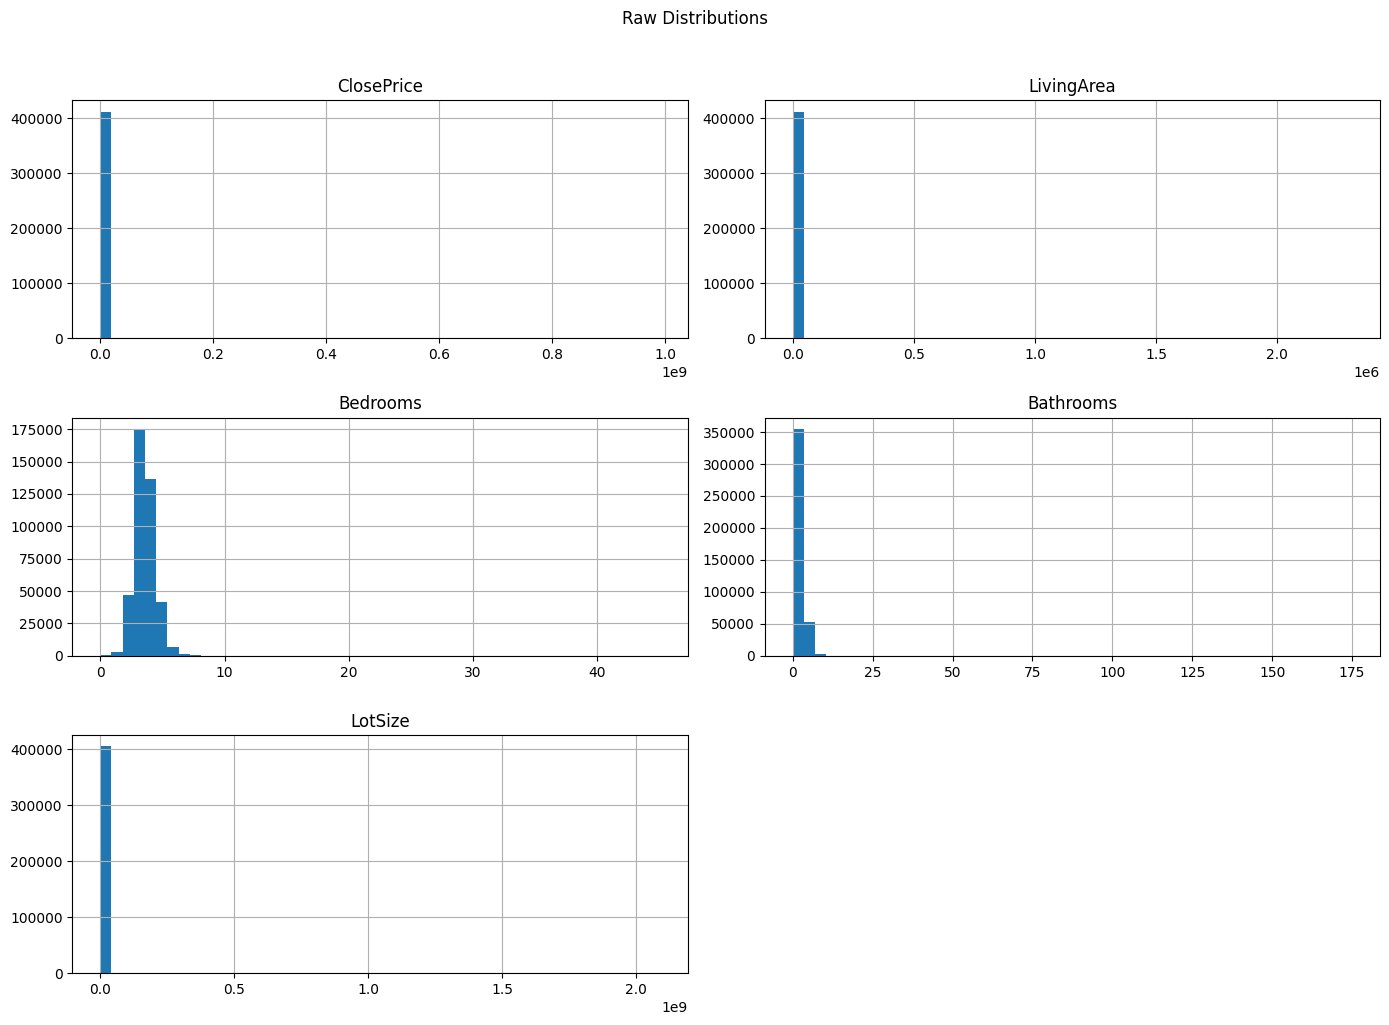

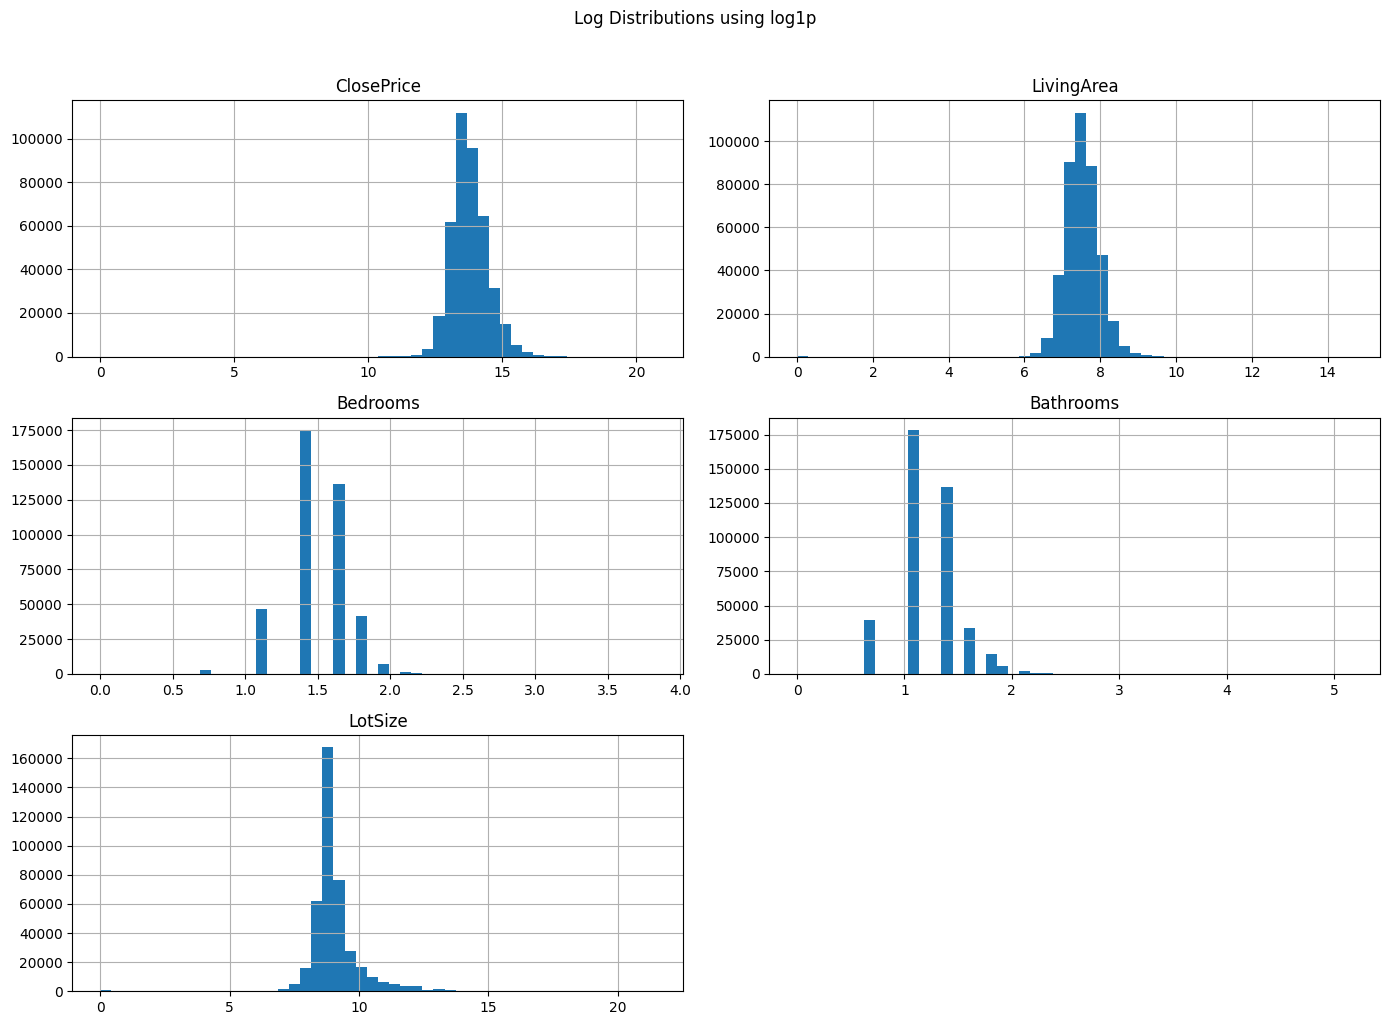

In [10]:
single_family[eda_columns].hist(bins=50, figsize=(14, 10))
plt.suptitle('Raw Distributions', y=1.02)
plt.tight_layout()
plt.show()

log_data = single_family[eda_columns].copy()

for column in eda_columns:
    log_data[column] = log_data[column].where(log_data[column] >= 0)
    log_data[column] = np.log1p(log_data[column])

log_data.hist(bins=50, figsize=(14, 10))
plt.suptitle('Log Distributions using log1p', y=1.02)
plt.tight_layout()
plt.show()

## 11. Quick observations

- `ClosePrice`, `LivingArea`, and `LotSize` are right-skewed.
- `Bedrooms` and `Bathrooms` are count-like variables, so their distributions are more discrete.
- The quantile table and outlier table show large high-end values, especially for `ClosePrice` and `LotSize`.
- For modeling later, it may be useful to consider log transformations for very skewed variables such as `ClosePrice`, `LivingArea`, and `LotSize`.
